# UMAR Quantile Reproduction

This notebook reads the cleaned UMAR simulator outputs from this reproduction repo and constructs the adjusted upper quantile curve for the scenario-level variance discrepancy.

## Reader Guide

The main object plotted here is a scenario-level fidelity curve, not a row-level prediction metric.

Objects used in the notebook:
- `psi`: coarse operational scenario defined in the simulator notebook
- `p_j`: real-side parameter for scenario `psi_j`
- `q_j`: simulator-side parameter for scenario `psi_j`
- parameter of interest in this notebook: the variance of future 30-minute room temperature within scenario `psi_j`
- `gamma_j = 1 - n_j^{-1/3}`: scenario-specific confidence level
- `bar_gamma_m`: average of the scenario-specific `gamma_j` values, used in the asymptotic index adjustment

The default presentation keeps the focus narrow:
- cleaned data only
- variance target only
- adjusted upper curve as the main figure

## What This Notebook Is Aiming To Show

The motivating question is not simply which model has the best RMSE. The paper-facing question is which simulator family better reproduces the scenario-level variability seen in the real UMAR building data.

The default comparison therefore does the following for each model and each scenario `psi`:
1. trim the same rare extreme-temperature artifact windows used in the cleaned experiment
2. estimate the real-side scenario variance
3. build a scenario-specific bootstrap confidence interval for that variance
4. estimate the simulator-side scenario variance
5. compute upper and lower pseudo-discrepancy values
6. aggregate those scenario-level discrepancies into an adjusted quantile curve

In [1]:
from pathlib import Path
import sys
import json
import warnings
import zlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'umar_quantile' / 'output' / 'umar_simulator_config.json').exists() and (candidate / 'umar_quantile').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run the UMAR simulator notebook in this repo first.')

UMAR_DIR = PROJECT_ROOT / 'umar_quantile'
if str(UMAR_DIR) not in sys.path:
    sys.path.insert(0, str(UMAR_DIR))

from umar_utils import (
    add_model_annotations,
    build_asymptotic_quantile_curves,
    gamma_schedule_power,
    pseudo_delta_lower_variance,
    pseudo_delta_upper_variance,
)

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

OUTPUT_DIR = PROJECT_ROOT / 'umar_quantile' / 'output'
FIGURE_DIR = PROJECT_ROOT / 'umar_quantile' / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)
config = json.loads((OUTPUT_DIR / 'umar_simulator_config.json').read_text())
oof_real_df = pd.read_parquet(OUTPUT_DIR / 'umar_oof_real.parquet')
q_samples_df = pd.read_parquet(OUTPUT_DIR / 'umar_oof_q_samples.parquet')

TAU_GRID = np.linspace(1e-3, 1.0 - 1e-3, 201)
PRIMARY_BETA = 1.0 / 3.0
VARIANCE_LOSS_KIND = 'sq'
VARIANCE_BOOTSTRAPS = 400
ARTIFACT_TEMP_THRESHOLD_C = float(config['artifact_temp_threshold_c'])

display(pd.DataFrame(config['model_catalog']))
print('artifact threshold (C):', ARTIFACT_TEMP_THRESHOLD_C)
print('configured models:', [m['model_display_name'] for m in config['model_catalog']])

,model_name,model_display_name,literature_family,paper_alignment_note
0,DecisionTree,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
1,LinearModel,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
2,MLP,Multilayer Perceptron (MLP / ANN),Artificial neural network family,Used here as an ANN/MLP representative from th...


artifact threshold (C): 30.0
configured models: ['Decision Tree (DT)', 'Linear Regression', 'Multilayer Perceptron (MLP / ANN)']


## Scenario-Level Variance Comparison

The real-side and simulator-side samples are grouped by scenario `psi`. Within each scenario:
- the same artifact threshold is applied again to the real and simulated target values
- `gamma_j` is computed from the trimmed real-side sample size `n_j`
- a bootstrap variance confidence interval is constructed for the real side
- the simulator-side variance is compared against that interval using the chosen loss function

Loss used here:
- squared loss on the variance target

In [2]:
real_by_psi = {psi: grp['y_real'].to_numpy(dtype=float) for psi, grp in oof_real_df.groupby('psi')}
rows = []
for model_name in sorted(q_samples_df['model_name'].unique()):
    sim_by_psi = {psi: grp['y_sim'].to_numpy(dtype=float) for psi, grp in q_samples_df[q_samples_df['model_name'] == model_name].groupby('psi')}
    for psi_value in sorted(real_by_psi):
        y_real = real_by_psi[psi_value]
        y_sim = sim_by_psi[psi_value]
        y_real_trim = y_real[np.isfinite(y_real) & (y_real <= ARTIFACT_TEMP_THRESHOLD_C)]
        y_sim_trim = y_sim[np.isfinite(y_sim) & (y_sim <= ARTIFACT_TEMP_THRESHOLD_C)]
        if len(y_real_trim) < 2 or len(y_sim_trim) < 2:
            continue
        gamma_j = gamma_schedule_power(len(y_real_trim), beta=PRIMARY_BETA)
        seed = zlib.adler32(f'{model_name}|{psi_value}|variance_trim_main'.encode('utf-8'))
        delta_plus, plus_info = pseudo_delta_upper_variance(
            y_real=y_real_trim,
            y_sim=y_sim_trim,
            gamma=gamma_j,
            loss_kind=VARIANCE_LOSS_KIND,
            n_boot=VARIANCE_BOOTSTRAPS,
            rng=seed,
        )
        delta_minus, minus_info = pseudo_delta_lower_variance(
            y_real=y_real_trim,
            y_sim=y_sim_trim,
            gamma=gamma_j,
            loss_kind=VARIANCE_LOSS_KIND,
            n_boot=VARIANCE_BOOTSTRAPS,
            rng=seed,
        )
        rows.append({
            'model_name': model_name,
            'psi': psi_value,
            'n_j_original': int(len(y_real)),
            'n_j_trimmed': int(len(y_real_trim)),
            'k_j_original': int(len(y_sim)),
            'k_j_trimmed': int(len(y_sim_trim)),
            'n_removed_real': int(len(y_real) - len(y_real_trim)),
            'n_removed_sim': int(len(y_sim) - len(y_sim_trim)),
            'gamma_j': float(gamma_j),
            'p_hat_var': float(plus_info['p_hat']),
            'q_hat_var': float(plus_info['q_hat']),
            'ci_lower_var': float(plus_info['ci_lower']),
            'ci_upper_var': float(plus_info['ci_upper']),
            'variance_ci_width': float(plus_info['ci_upper'] - plus_info['ci_lower']),
            'variance_abs_gap': float(abs(plus_info['q_hat'] - plus_info['p_hat'])),
            'delta_plus_var': float(delta_plus),
            'delta_minus_var': float(delta_minus),
            'variance_n_boot': int(plus_info['n_boot']),
            'artifact_temp_threshold_c': ARTIFACT_TEMP_THRESHOLD_C,
        })

variance_df = add_model_annotations(pd.DataFrame(rows))
curve_rows = []
summary_rows = []
for model_name, sub in variance_df.groupby('model_name'):
    curve_df, info = build_asymptotic_quantile_curves(
        delta_plus=sub['delta_plus_var'].to_numpy(dtype=float),
        delta_minus=sub['delta_minus_var'].to_numpy(dtype=float),
        gamma_values=sub['gamma_j'].to_numpy(dtype=float),
        tau_grid=TAU_GRID,
    )
    curve_df['model_name'] = model_name
    curve_rows.append(curve_df)
    summary_rows.append({
        'model_name': model_name,
        'm_trimmed': int(sub['psi'].nunique()),
        'bar_gamma': float(info['bar_gamma']),
        'mean_p_hat_var': float(sub['p_hat_var'].mean()),
        'mean_q_hat_var': float(sub['q_hat_var'].mean()),
        'mean_variance_ci_width': float(sub['variance_ci_width'].mean()),
        'mean_variance_abs_gap': float(sub['variance_abs_gap'].mean()),
        'variance_upper_auc_shifted': float(np.trapz(curve_df['v_plus'], curve_df['tau'])),
        'max_delta_plus_var': float(sub['delta_plus_var'].max()),
        'total_real_rows_removed': int(sub['n_removed_real'].sum()),
        'total_sim_rows_removed': int(sub['n_removed_sim'].sum()),
    })
variance_curve_df = add_model_annotations(pd.concat(curve_rows, ignore_index=True))
variance_summary_df = add_model_annotations(pd.DataFrame(summary_rows)).sort_values('variance_upper_auc_shifted').reset_index(drop=True)

gamma_audit_df = (
    variance_df.groupby('model_name', as_index=False)
    .agg(
        m=('psi', 'nunique'),
        min_gamma=('gamma_j', 'min'),
        mean_gamma=('gamma_j', 'mean'),
        max_gamma=('gamma_j', 'max'),
        mean_n_trimmed=('n_j_trimmed', 'mean'),
        min_n_trimmed=('n_j_trimmed', 'min'),
        max_n_trimmed=('n_j_trimmed', 'max'),
    )
)
gamma_audit_df = add_model_annotations(gamma_audit_df)

real_rows_removed = int((oof_real_df['y_real'] > ARTIFACT_TEMP_THRESHOLD_C).sum())
real_scenarios_touched = int((oof_real_df.groupby('psi')['y_real'].apply(lambda s: (s > ARTIFACT_TEMP_THRESHOLD_C).any())).sum())
print('real rows removed by threshold:', real_rows_removed)
print('real scenarios touched by threshold:', real_scenarios_touched)
display(variance_summary_df)
display(gamma_audit_df)
display(variance_df.sort_values('delta_plus_var', ascending=False).head(12))

real rows removed by threshold: 0
real scenarios touched by threshold: 0


,model_name,m_trimmed,bar_gamma,mean_p_hat_var,mean_q_hat_var,mean_variance_ci_width,mean_variance_abs_gap,variance_upper_auc_shifted,max_delta_plus_var,total_real_rows_removed,total_sim_rows_removed,model_display_name,literature_family,paper_alignment_note
0,LinearModel,192,0.846662,1.551547,1.552474,0.485151,0.181736,0.261726,1.507813,0,0,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
1,MLP,192,0.846662,1.551547,1.545537,0.482122,0.185893,0.270551,1.620447,0,0,Multilayer Perceptron (MLP / ANN),Artificial neural network family,Used here as an ANN/MLP representative from th...
2,DecisionTree,192,0.846662,1.551547,1.401896,0.487061,0.265226,0.440325,4.505395,0,0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...


,model_name,m,min_gamma,mean_gamma,max_gamma,mean_n_trimmed,min_n_trimmed,max_n_trimmed,model_display_name,literature_family,paper_alignment_note
0,DecisionTree,192,0.702556,0.846662,0.893677,348.552083,38,832,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
1,LinearModel,192,0.702556,0.846662,0.893677,348.552083,38,832,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
2,MLP,192,0.702556,0.846662,0.893677,348.552083,38,832,Multilayer Perceptron (MLP / ANN),Artificial neural network family,Used here as an ANN/MLP representative from th...


,model_name,psi,n_j_original,n_j_trimmed,k_j_original,k_j_trimmed,n_removed_real,n_removed_sim,gamma_j,p_hat_var,q_hat_var,ci_lower_var,ci_upper_var,variance_ci_width,variance_abs_gap,delta_plus_var,delta_minus_var,variance_n_boot,artifact_temp_threshold_c,model_display_name,literature_family,paper_alignment_note
26,DecisionTree,h=12|w=0|tq=2,472,472,200,200,0,0,0.871564,3.409289,1.839297,2.934864,3.961889,1.027025,1.569992,4.505395,1.200267,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
18,DecisionTree,h=11|w=0|tq=2,499,499,200,200,0,0,0.873924,3.083978,1.705751,2.667544,3.546464,0.878919,1.378228,3.388224,0.925047,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
17,DecisionTree,h=11|w=0|tq=1,458,458,200,200,0,0,0.870269,2.756524,1.519796,2.282797,3.297221,1.014425,1.236729,3.159242,0.582171,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
25,DecisionTree,h=12|w=0|tq=1,446,446,200,200,0,0,0.869115,2.869809,1.627880,2.450927,3.326041,0.875115,1.241929,2.883751,0.677405,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
10,DecisionTree,h=10|w=0|tq=2,509,509,200,200,0,0,0.874755,2.392819,1.394434,2.056174,2.814440,0.758265,0.998385,2.016416,0.437900,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
413,MLP,h=12|w=1|tq=1,199,199,200,200,0,0,0.828716,2.831910,3.662286,2.389318,3.241371,0.852053,0.830376,1.620447,0.177169,400,30.0,Multilayer Perceptron (MLP / ANN),Artificial neural network family,Used here as an ANN/MLP representative from th...
34,DecisionTree,h=13|w=0|tq=2,455,455,200,200,0,0,0.869984,3.046999,2.174905,2.568891,3.447543,0.878652,0.872094,1.619608,0.155225,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
9,DecisionTree,h=10|w=0|tq=1,485,485,200,200,0,0,0.872722,2.517765,1.665590,2.125542,2.927396,0.801854,0.852176,1.592154,0.211556,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
57,DecisionTree,h=16|w=0|tq=1,421,421,200,200,0,0,0.866574,2.487084,1.628779,2.086252,2.861886,0.775634,0.858304,1.520552,0.209281,400,30.0,Decision Tree (DT),Decision-tree family,Included as a deliberately shallow decision-tr...
225,LinearModel,h=13|w=0|tq=1,433,433,200,200,0,0,0.867818,2.574363,3.432401,2.204470,2.947341,0.742871,0.858038,1.507813,0.235283,400,30.0,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...


## Main Figure

This is the archived UMAR figure for the paper reproduction. It is saved to `umar_quantile/figures/`.

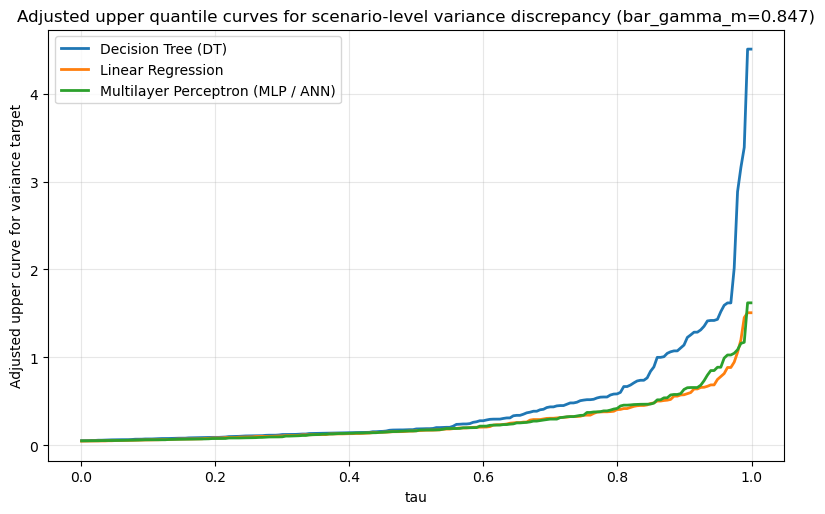

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
for model_name, sub in variance_curve_df.groupby('model_name'):
    ax.plot(sub['tau'], sub['v_plus'], label=sub['model_display_name'].iloc[0], linewidth=2)
shared_bar_gamma = float(variance_summary_df['bar_gamma'].iloc[0])
ax.set_title(f'Adjusted upper quantile curves for scenario-level variance discrepancy (bar_gamma_m={shared_bar_gamma:.3f})')
ax.set_xlabel('tau')
ax.set_ylabel('Adjusted upper curve for variance target')
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(FIGURE_DIR / 'umar_main_variance_adjusted_upper_curves.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## Saved Outputs

The CSV summaries are written to `umar_quantile/output/`, and the archived main figure is written to `umar_quantile/figures/`.

In [4]:
variance_df.to_csv(OUTPUT_DIR / 'umar_main_variance_scenario_discrepancy.csv', index=False)
variance_curve_df.to_csv(OUTPUT_DIR / 'umar_main_variance_quantile_curves.csv', index=False)
variance_summary_df.to_csv(OUTPUT_DIR / 'umar_main_variance_model_summary.csv', index=False)

print('saved main inference outputs:')
for p in [
    FIGURE_DIR / 'umar_main_variance_adjusted_upper_curves.png',
    OUTPUT_DIR / 'umar_main_variance_scenario_discrepancy.csv',
    OUTPUT_DIR / 'umar_main_variance_quantile_curves.csv',
    OUTPUT_DIR / 'umar_main_variance_model_summary.csv',
]:
    print(' -', p.relative_to(PROJECT_ROOT))

saved main inference outputs:
 - umar_quantile/figures/umar_main_variance_adjusted_upper_curves.png
 - umar_quantile/output/umar_main_variance_scenario_discrepancy.csv
 - umar_quantile/output/umar_main_variance_quantile_curves.csv
 - umar_quantile/output/umar_main_variance_model_summary.csv


## Optional Analyses (Disabled By Default)

The older exploratory mean-based, Wasserstein, and robustness analyses are intentionally not run in the default workflow. They can be reintroduced later, but the current notebook is meant to stay tightly focused on the cleaned variance result.

In [5]:
RUN_OPTIONAL_ANALYSES = False

# if RUN_OPTIONAL_ANALYSES:
#     # Reintroduce mean-based curves, Wasserstein diagnostics,
#     # beta sensitivity, or human-n robustness only when needed.
#     pass

print('Optional analyses enabled:', RUN_OPTIONAL_ANALYSES)

Optional analyses enabled: False
